In [155]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [156]:
# CSV file path in Google Drive
# file_path = '/content/drive/MyDrive/Dataset/DigitalExposome Dataset.csv'
file_path = '../DigitalExposome Dataset.csv'
# Load dataset using Pandas
df = pd.read_csv(file_path)

# Display the top 5 rows of the dataset
df.head()

,IBI,HR,NO2,Noise,NH3,PM10,CO,PM25,Label,PM1,EDA,BVP
0,0.0,0.377574,0.0,0.511358,0.003018,0.003091,0.871758,0.000000,5,0.000000,0.0,0.0
1,0.0,0.196398,0.0,0.490903,0.003018,0.003091,0.876848,0.003091,5,0.001854,0.0,0.0
2,0.0,0.454163,0.0,0.470449,0.006036,0.006181,0.881939,0.006181,5,0.003709,0.0,0.0
3,0.0,0.322451,0.0,0.449995,0.009055,0.009272,0.887030,0.009272,5,0.005563,0.0,0.0
4,0.0,0.237595,0.0,0.429540,0.012073,0.012362,0.892121,0.012362,5,0.007417,0.0,0.0


In [157]:
df.describe()

,IBI,HR,NO2,Noise,NH3,PM10,CO,PM25,Label,PM1,EDA,BVP
count,42436.000000,42436.000000,42436.000000,42436.000000,42436.000000,42436.000000,42436.000000,42436.000000,42436.000000,42436.000000,42436.000000,42436.000000
mean,0.178688,0.530687,0.502239,0.427541,0.564276,0.208474,0.679874,0.224901,3.326185,0.230773,0.260318,0.482902
std,0.230127,0.266531,0.274914,0.247601,0.294515,0.210981,0.308111,0.223242,1.599863,0.255253,0.221725,0.175569
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,0.000000,0.309505,0.285412,0.214008,0.305285,0.017624,0.458047,0.012362,2.000000,0.006310,0.060686,0.449963
50%,0.016760,0.491213,0.489703,0.403671,0.644756,0.158454,0.805352,0.176150,4.000000,0.176316,0.216064,0.512280
75%,0.309984,0.776388,0.736983,0.618592,0.826943,0.326889,0.909832,0.376813,5.000000,0.407268,0.421109,0.579756
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,1.000000,5.000000,24.000000,1.000000,1.000000


In [158]:
print("Shape:", df.shape)
print("Columns:", df.columns)

Shape: (42436, 12)
Columns: Index(['IBI', 'HR', 'NO2', 'Noise', 'NH3', 'PM10', 'CO', 'PM25', 'Label',
       'PM1', 'EDA', 'BVP'],
      dtype='object')


# Check Data type

In [159]:
print("\nData Types:")
df.info()


Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42436 entries, 0 to 42435
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   IBI     42436 non-null  float64
 1   HR      42436 non-null  float64
 2   NO2     42436 non-null  float64
 3   Noise   42436 non-null  float64
 4   NH3     42436 non-null  float64
 5   PM10    42436 non-null  float64
 6   CO      42436 non-null  float64
 7   PM25    42436 non-null  float64
 8   Label   42436 non-null  int64  
 9   PM1     42436 non-null  float64
 10  EDA     42436 non-null  float64
 11  BVP     42436 non-null  float64
dtypes: float64(11), int64(1)
memory usage: 3.9 MB


In [160]:
# cek missing value
df.isnull().sum()

IBI      0
HR       0
NO2      0
Noise    0
NH3      0
PM10     0
CO       0
PM25     0
Label    0
PM1      0
EDA      0
BVP      0
dtype: int64

In [161]:
# Duplicated
df.duplicated().sum()

14342

In [162]:
# Cek data NaN
df.isna().sum()

IBI      0
HR       0
NO2      0
Noise    0
NH3      0
PM10     0
CO       0
PM25     0
Label    0
PM1      0
EDA      0
BVP      0
dtype: int64

## Prepocessing

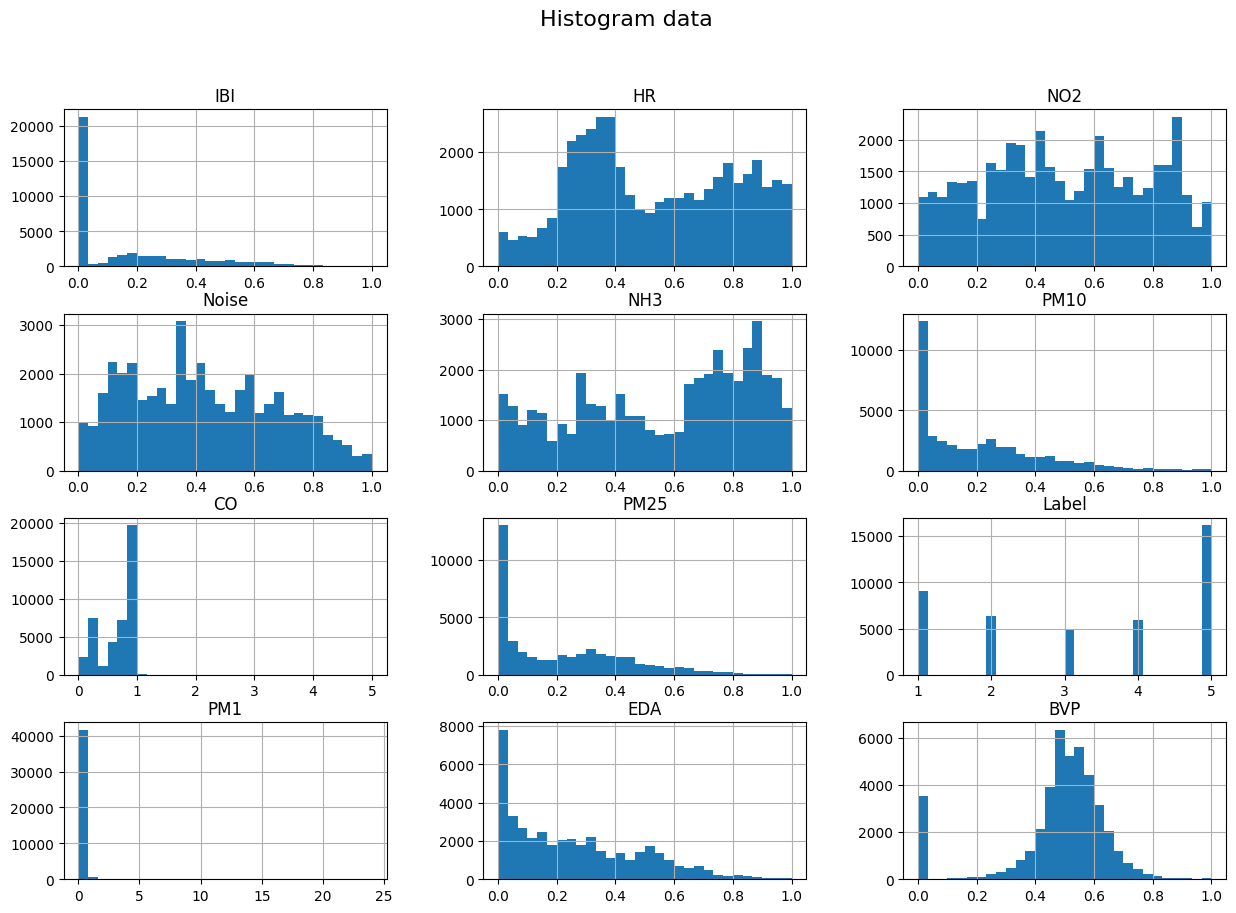

In [163]:
df.hist(bins=30, figsize=(15, 10))
plt.suptitle("Histogram data", fontsize=16)
plt.show()

In [164]:
df.shape

(42436, 12)

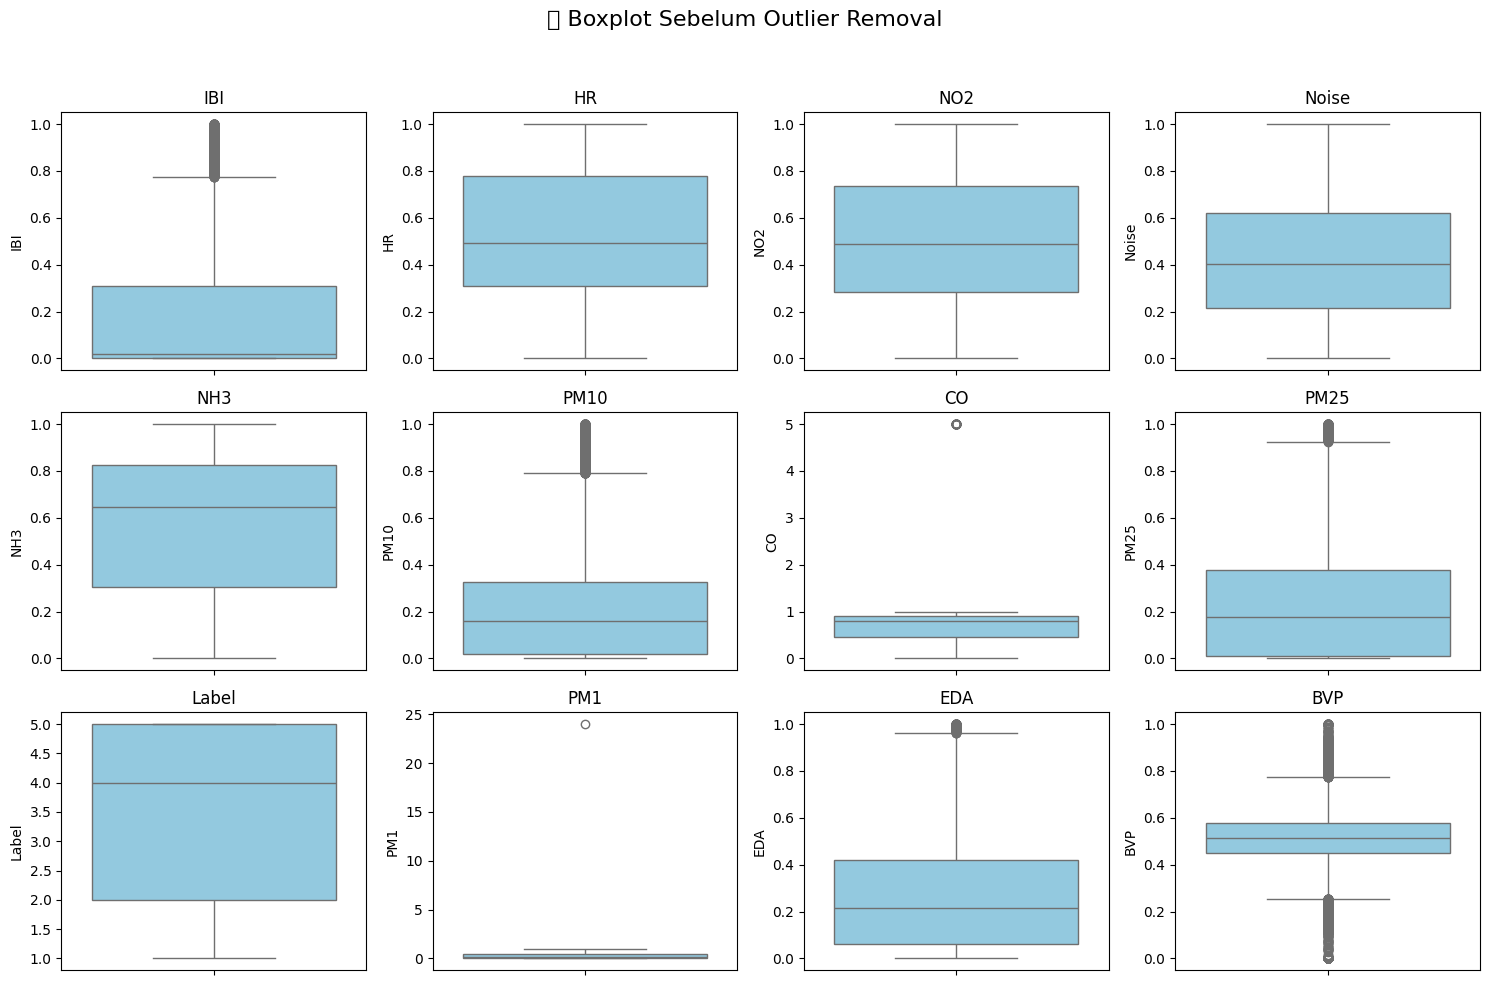

In [165]:
# Simpan salinan data sebelum outlier removal (untuk visualisasi)
df_before_outlier = df.copy()
import matplotlib.pyplot as plt
import seaborn as sns

# Buat grid layout otomatis sesuai jumlah kolom
n_cols = 4  # jumlah boxplot per baris
n_rows = -(-len(df.columns) // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 10))
axes = axes.flatten()  # supaya bisa diiterasi

for i, col in enumerate(df.columns):
    sns.boxplot(y=df_before_outlier[col], color='skyblue', ax=axes[i])
    axes[i].set_title(f"{col}")

# Hapus axis kosong kalau jumlah kolom tidak pas
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("📊 Boxplot Sebelum Outlier Removal", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [166]:
### Outlier Detection and Removal using Z-score
z_scores = np.abs(stats.zscore(df))
df = df[(z_scores < 3).all(axis=1)]  # Keep only rows where all Z-scores < 3

In [167]:
print("Shape after removing outliers:", df.shape)

Shape after removing outliers: (41189, 12)



📊 Boxplot Setelah Outlier Removal


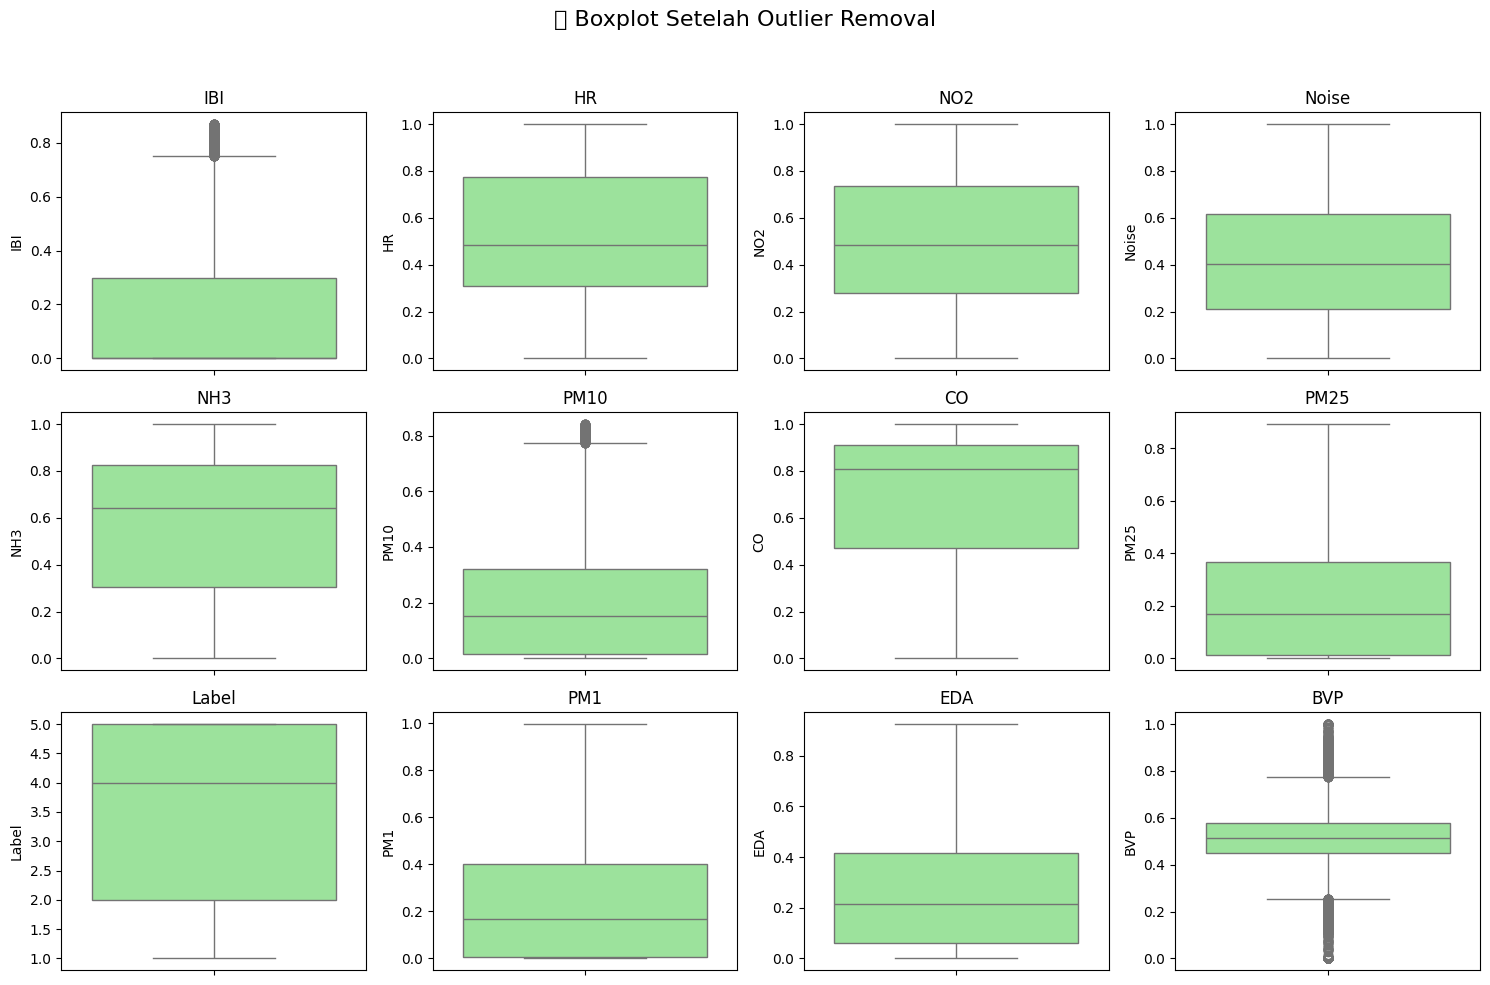

In [168]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\n📊 Boxplot Setelah Outlier Removal")

# Tentukan layout grid
n_cols = 4  # jumlah boxplot per baris
n_rows = -(-len(df.columns) // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 10))
axes = axes.flatten()

# Loop setiap kolom dan pasang boxplot ke grid
for i, col in enumerate(df.columns):
    sns.boxplot(y=df[col], color='lightgreen', ax=axes[i])
    axes[i].set_title(col)

# Hapus subplot kosong kalau jumlah kolom tidak pas
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Judul utama
fig.suptitle("📊 Boxplot Setelah Outlier Removal", fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


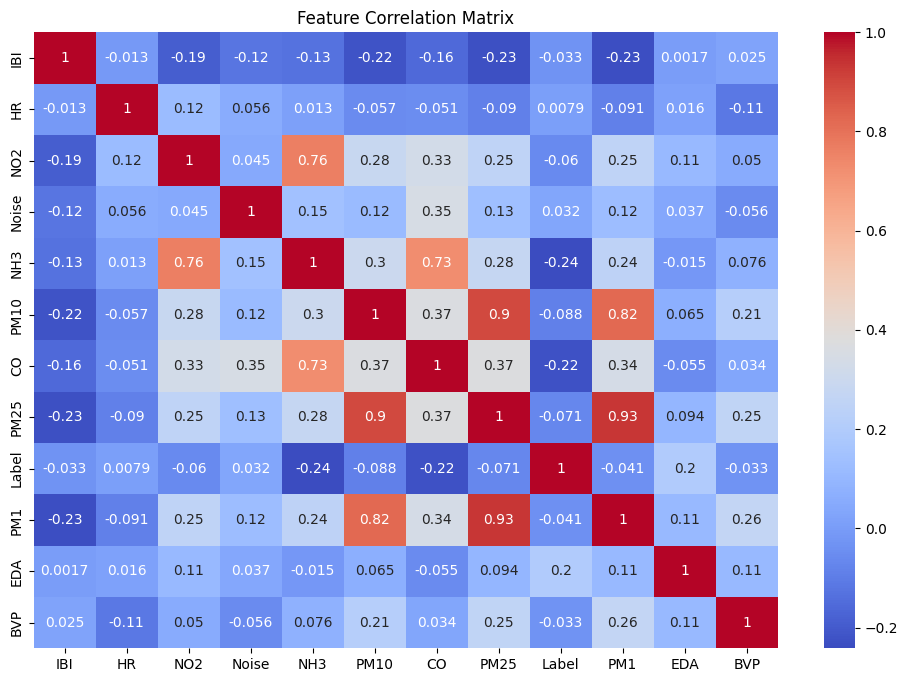

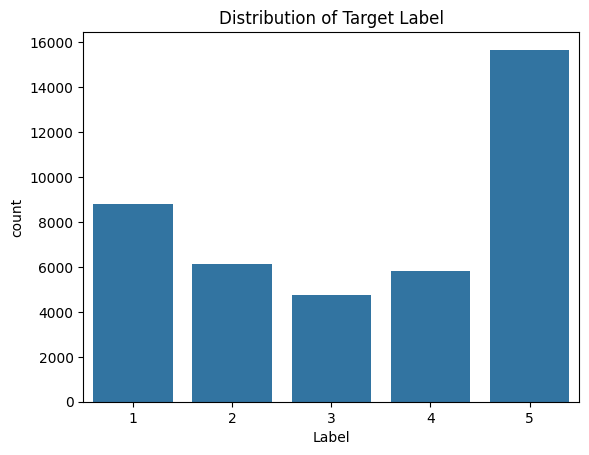

In [169]:
# Heatmap korelasi
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

# Distribusi Label
sns.countplot(x='Label', data=df)
plt.title("Distribution of Target Label")
plt.show()

In [170]:
# Memisahkan fitur (X) dan label (y)
X = df.drop('Label', axis=1)
y = df['Label']

print("Shape of features (X):", X.shape)
print("Shape of target (y):", y.shape)

Shape of features (X): (41189, 11)
Shape of target (y): (41189,)


In [171]:
print(X.info())
print(y.value_counts())

<class 'pandas.core.frame.DataFrame'>
Index: 41189 entries, 0 to 42435
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   IBI     41189 non-null  float64
 1   HR      41189 non-null  float64
 2   NO2     41189 non-null  float64
 3   Noise   41189 non-null  float64
 4   NH3     41189 non-null  float64
 5   PM10    41189 non-null  float64
 6   CO      41189 non-null  float64
 7   PM25    41189 non-null  float64
 8   PM1     41189 non-null  float64
 9   EDA     41189 non-null  float64
 10  BVP     41189 non-null  float64
dtypes: float64(11)
memory usage: 3.8 MB
None
Label
5    15671
1     8805
2     6137
4     5835
3     4741
Name: count, dtype: int64


In [172]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import ADASYN
from collections import Counter

# 2. Split train-test (tanpa oversampling dulu)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Distribusi sebelum ADASYN :")
print("Train:", Counter(y_train))
print("Test :", Counter(y_test))

# 3. Terapkan ADASYN hanya ke training data
adasyn = ADASYN(random_state=42)
X_train_ada, y_train_ada = adasyn.fit_resample(X_train, y_train)

print("\nDistribusi setelah ADASYN (hanya train):")
print("Train ADASYN:", Counter(y_train_ada))
print("Test tetap :", Counter(y_test))  # test tidak berubah


Distribusi sebelum ADASYN :
Train: Counter({5: 12537, 1: 7044, 2: 4909, 4: 4668, 3: 3793})
Test : Counter({5: 3134, 1: 1761, 2: 1228, 4: 1167, 3: 948})

Distribusi setelah ADASYN (hanya train):
Train ADASYN: Counter({1: 12738, 2: 12705, 5: 12537, 4: 12472, 3: 12329})
Test tetap : Counter({5: 3134, 1: 1761, 2: 1228, 4: 1167, 3: 948})


## Prepocessing

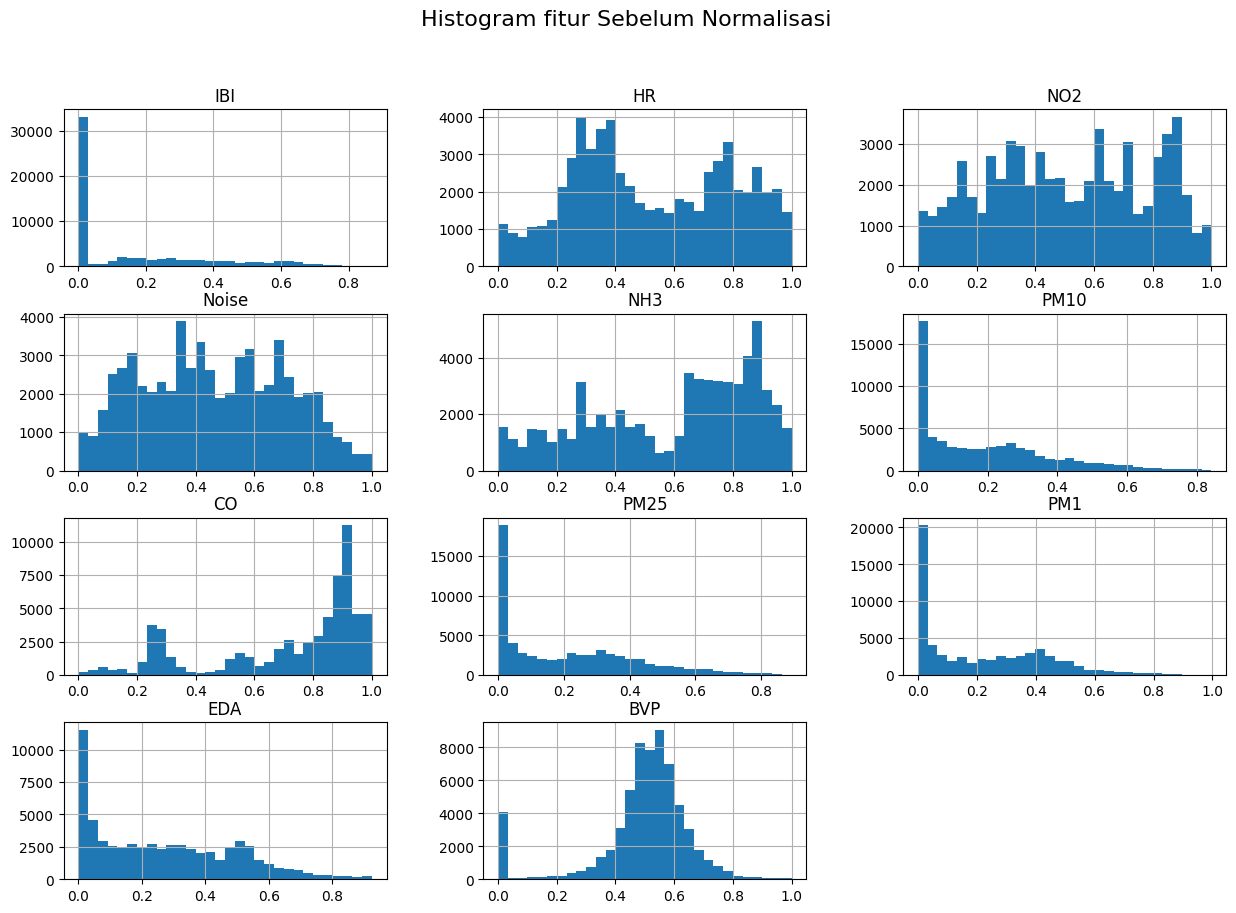

In [173]:
# Histogram sebelum normalisasi
X_train_ada.hist(bins=30, figsize=(15, 10))
plt.suptitle("Histogram fitur Sebelum Normalisasi", fontsize=16)
plt.show()

In [174]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_ada)
X_test_scaled = scaler.transform(X_test)

print(f"Data Train after normalisation = {X_train_scaled.shape}")
print(f"Data Test after normalisation = {X_test_scaled.shape}")

Data Train after normalisation = (62781, 11)
Data Test after normalisation = (8238, 11)


In [175]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_ada = le.fit_transform(y_train_ada)
y_test = le.transform(y_test)


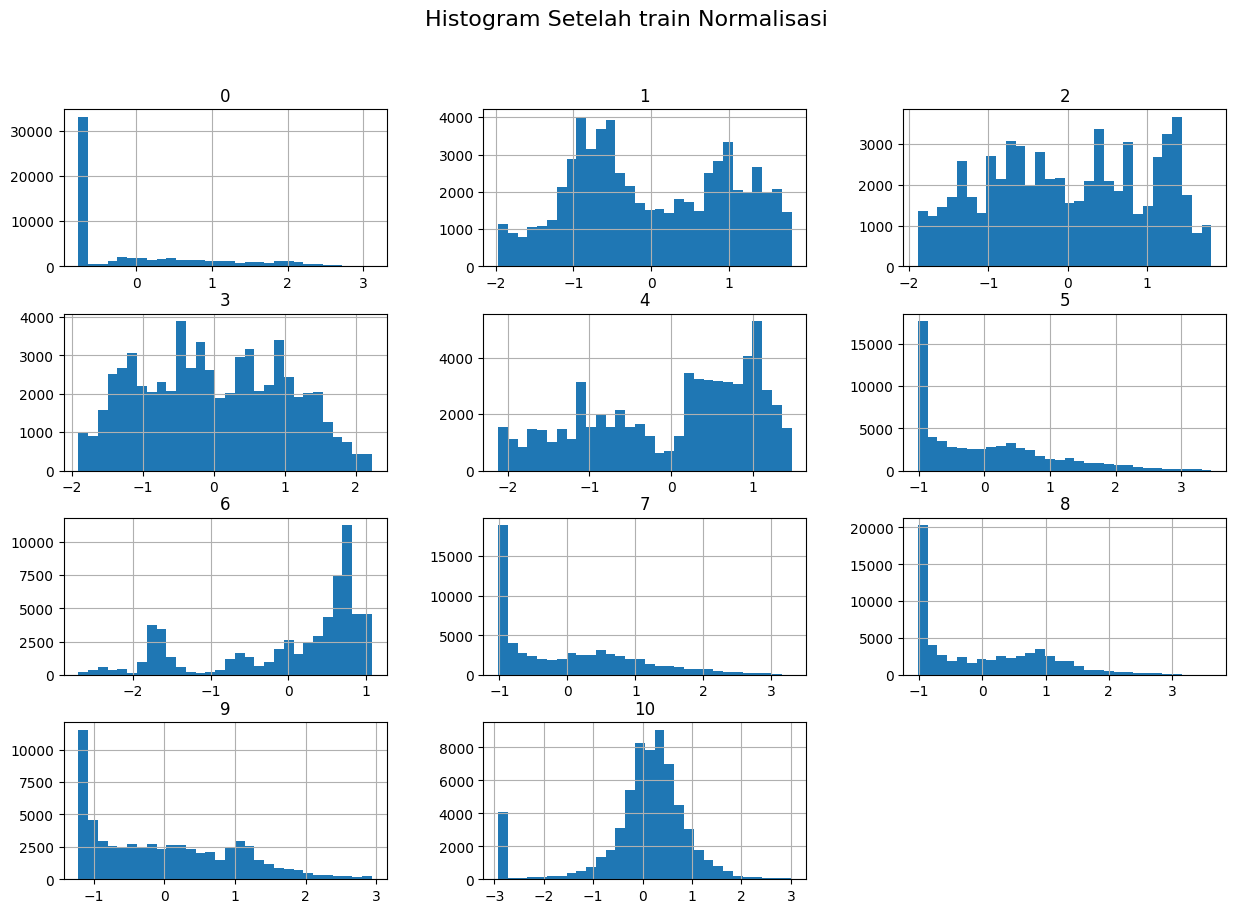

In [176]:
# Histogram setelah normalisasi
X_train_scaled_df = pd.DataFrame(X_train_scaled)
X_train_scaled_df.hist(bins=30, figsize=(15, 10))
plt.suptitle("Histogram Setelah train Normalisasi", fontsize=16)
plt.show()

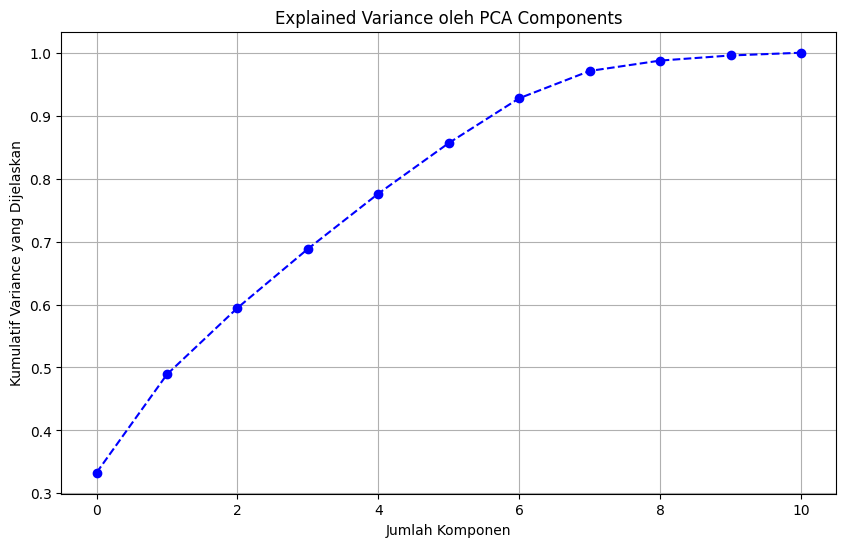

In [177]:
# Inisialisasi PCA tanpa mengurangi dimensi dulu (hanya untuk melihat explained variance)
pca = PCA(n_components=None) # Set n_components to None to keep all components initially
pca.fit(X_train_scaled)

# Plot explained variance ratio
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--', color='b')
plt.xlabel('Jumlah Komponen')
plt.ylabel('Kumulatif Variance yang Dijelaskan')
plt.title('Explained Variance oleh PCA Components')
plt.grid(True)
plt.show()

In [178]:
# Tampilkan variansi kumulatif
explained_variance = np.cumsum(pca.explained_variance_ratio_)
for i, var in enumerate(explained_variance):
    print(f"Komponen ke-{i+1}: {var:.4f} variance terjelaskan")

# Misal ingin menyimpan komponen yang menjelaskan >=90% variance
n_components = np.argmax(explained_variance >= 0.90) + 1
print(f"\n🔍 Jumlah komponen optimal (≥90% variance): {n_components}")

Komponen ke-1: 0.3328 variance terjelaskan
Komponen ke-2: 0.4890 variance terjelaskan
Komponen ke-3: 0.5945 variance terjelaskan
Komponen ke-4: 0.6883 variance terjelaskan
Komponen ke-5: 0.7762 variance terjelaskan
Komponen ke-6: 0.8565 variance terjelaskan
Komponen ke-7: 0.9277 variance terjelaskan
Komponen ke-8: 0.9710 variance terjelaskan
Komponen ke-9: 0.9875 variance terjelaskan
Komponen ke-10: 0.9956 variance terjelaskan
Komponen ke-11: 1.0000 variance terjelaskan

🔍 Jumlah komponen optimal (≥90% variance): 7


In [179]:
from sklearn.decomposition import PCA

# Inisialisasi PCA dengan 7 komponen
pca = PCA(n_components=7)

# Fit hanya di data train
X_train_pca = pca.fit_transform(X_train_scaled)

# Transform data test pakai PCA yang sudah fit dari train
X_test_pca = pca.transform(X_test_scaled)

print("Shape train PCA:", X_train_pca.shape)
print("Shape test PCA:", X_test_pca.shape)


Shape train PCA: (62781, 7)
Shape test PCA: (8238, 7)


## Training Data

In [180]:
# ==========================
# IMPORT LIBRARY
# ==========================
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    ExtraTreesClassifier,
    VotingClassifier,
)
from sklearn.tree import DecisionTreeClassifier
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Boosting eksternal
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


# ==========================
# FUNGSI EVALUASI ENSEMBLE
# ==========================
def evaluate_ensemble_models(X_train, X_test, y_train, y_test,
                             percobaan="Ensemble", output_file="results2.csv"):

    # === Base models untuk voting ===
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    et = ExtraTreesClassifier(n_estimators=100, random_state=42)
    Dt = DecisionTreeClassifier(random_state=42)

    # === ENSEMBLE MODELS (SUDAH DIUPDATE) ===
    models = {
        "AdaBoost": AdaBoostClassifier(
            estimator=DecisionTreeClassifier(max_depth=1),
            n_estimators=50,
            random_state=42
        ),

        # === Gradient Boosting UPDATED ===
        "GradientBoosting": GradientBoostingClassifier(
            n_estimators=150,
            subsample=0.75,
            max_features=0.6,
            random_state=42
        ),

        "Voting (RF+ET+DT) soft": VotingClassifier(
            estimators=[("rf", rf), ("et", et), ("dt", Dt)],
            voting="soft"
        ),

        "Voting (RF+ET+DT) hard": VotingClassifier(
            estimators=[("rf", rf), ("et", et), ("dt", Dt)],
            voting="hard"
        ),

        # === XGBoost UPDATED ===
        "XGBoost": XGBClassifier(
            n_estimators=150,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.75,
            colsample_bynode=0.6,
            random_state=42,
            eval_metric="logloss"
        ),

        # === LightGBM UPDATED ===
        "LightGBM": LGBMClassifier(
            boosting_type="goss",
            n_estimators=150,
            learning_rate=0.05,
            colsample_bynode=0.6,
            max_depth=-1,
            num_leaves=31,
            random_state=42
        ),

        # === CatBoost UPDATED ===
        "CatBoost": CatBoostClassifier(
            iterations=150,
            depth=6,
            learning_rate=0.05,
            loss_function="MultiClass",
            random_state=42,
            verbose=0  # PENTING supaya tidak berisik
        )

    }

    rows = []

    # =========================================
    # TRAIN & EVALUASI SETIAP MODEL
    # =========================================
    for name, model in models.items():
        print(f"\n🔹 Training {name}...")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # Evaluasi
        report = classification_report(y_test, y_pred, output_dict=True)
        acc = report["accuracy"]
        prec = report["macro avg"]["precision"]
        rec = report["macro avg"]["recall"]
        f1 = report["macro avg"]["f1-score"]

        rows.append({
            "Percobaan": percobaan,
            "Model": name,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1-Score": f1
        })

        # Confusion Matrix
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
        plt.title(f"Confusion Matrix - {name}")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.tight_layout()
        plt.show()

    # =========================================
    # SIMPAN HASIL KE CSV
    # =========================================
    df_results = pd.DataFrame(rows)
    print("\n📊 Perbandingan Model Ensemble:")
    print(df_results)

    try:
        existing = pd.read_csv(output_file)
        df_results = pd.concat([existing, df_results], ignore_index=True)
    except FileNotFoundError:
        pass

    df_results.to_csv(output_file, index=False)

    # =========================================
    # VISUALISASI PERFORMA
    # =========================================
    df_plot = df_results[df_results["Percobaan"] == percobaan].set_index("Model")[[
        "Accuracy", "Precision", "Recall", "F1-Score"
    ]]

    df_plot.plot(kind="bar", figsize=(12, 6))
    plt.title(f"Perbandingan Model Ensemble - {percobaan}")
    plt.ylabel("Score")
    plt.xticks(rotation=45, ha="right")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

    return df_results


🔹 Training AdaBoost...


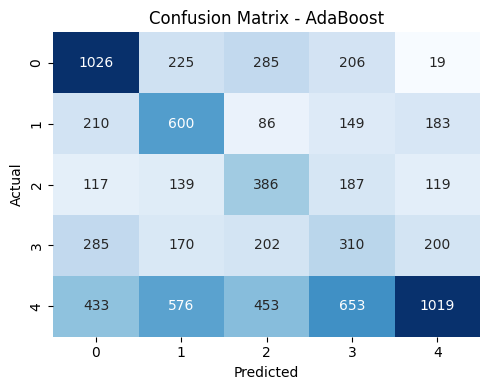


🔹 Training GradientBoosting...


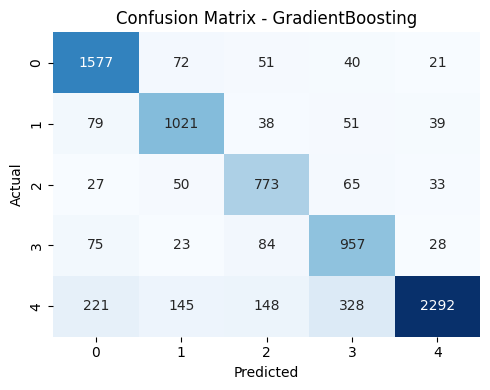


🔹 Training Voting (RF+ET+DT) soft...


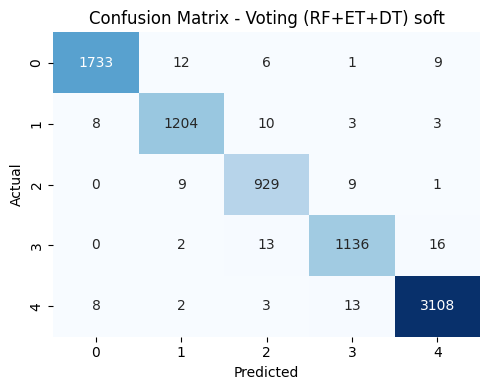


🔹 Training Voting (RF+ET+DT) hard...


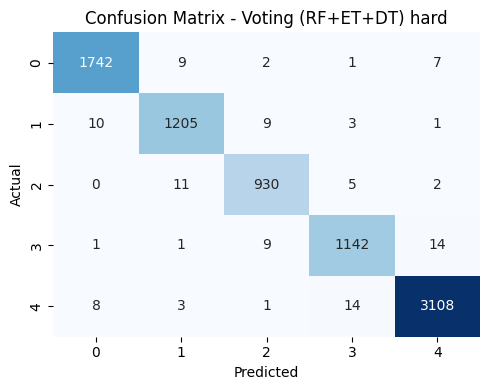


🔹 Training XGBoost...


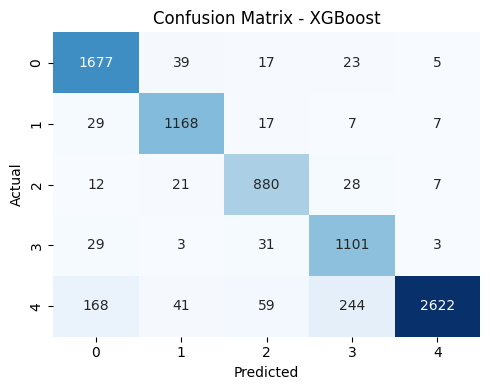


🔹 Training LightGBM...
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000741 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2805
[LightGBM] [Info] Number of data points in the train set: 62781, number of used features: 11
[LightGBM] [Info] Using GOSS
[LightGBM] [Info] Start training from score -1.595063
[LightGBM] [Info] Start training from score -1.597657
[LightGBM] [Info] Start training from score -1.627698
[Light

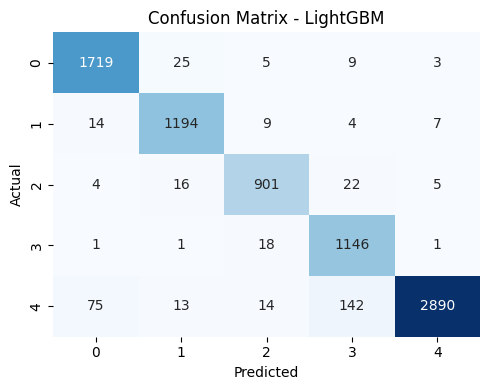


🔹 Training CatBoost...


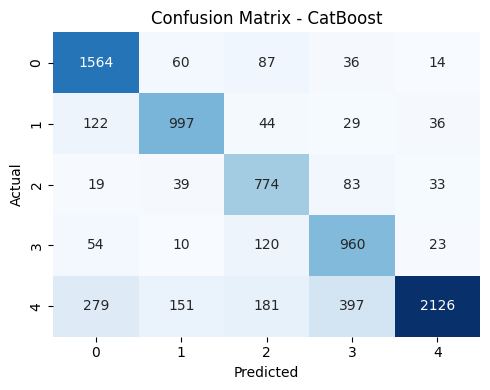


📊 Perbandingan Model Ensemble:
                           Percobaan                   Model  Accuracy  \
0  Baseline Performa Ensemble adasyn                AdaBoost  0.405560   
1  Baseline Performa Ensemble adasyn        GradientBoosting  0.803593   
2  Baseline Performa Ensemble adasyn  Voting (RF+ET+DT) soft  0.984462   
3  Baseline Performa Ensemble adasyn  Voting (RF+ET+DT) hard  0.986526   
4  Baseline Performa Ensemble adasyn                 XGBoost  0.904103   
5  Baseline Performa Ensemble adasyn                LightGBM  0.952901   
6  Baseline Performa Ensemble adasyn                CatBoost  0.779437   

   Precision    Recall  F1-Score  
0   0.397466  0.413836  0.387823  
1   0.779244  0.818747  0.792992  
2   0.981118  0.981931  0.981512  
3   0.984039  0.984355  0.984196  
4   0.889375  0.922357  0.902567  
5   0.943250  0.960607  0.950875  
6   0.758550  0.803493  0.771082  


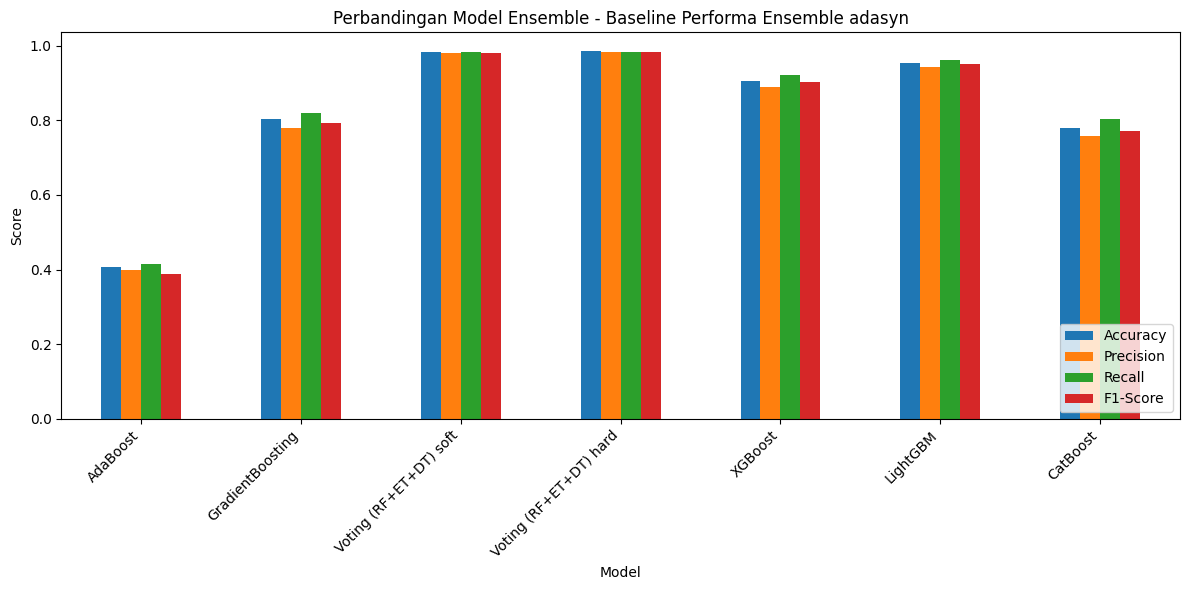

In [181]:
# === Cara pakai ===
df_results = evaluate_ensemble_models(
    X_train_ada, X_test, y_train_ada, y_test,
    percobaan="Baseline Performa Ensemble adasyn",
    output_file="hasil_ensemble1.csv"
)


🔹 Training AdaBoost...


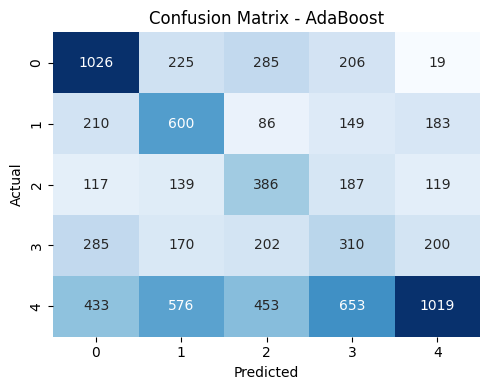


🔹 Training GradientBoosting...


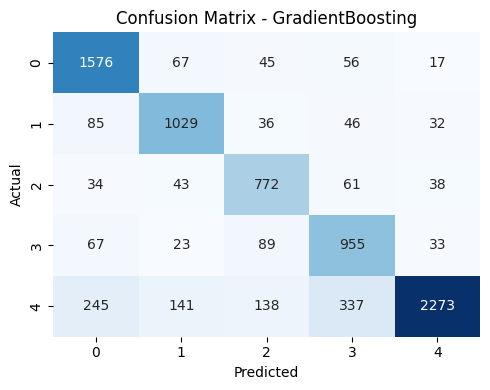


🔹 Training Voting (RF+ET+DT) soft...


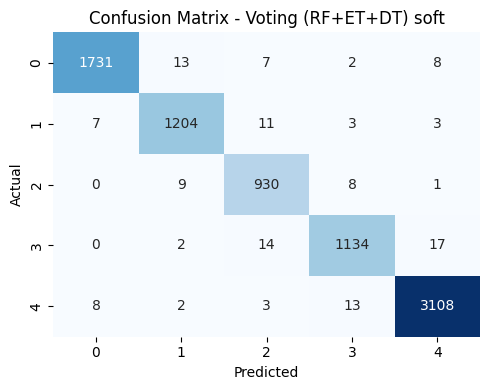


🔹 Training Voting (RF+ET+DT) hard...


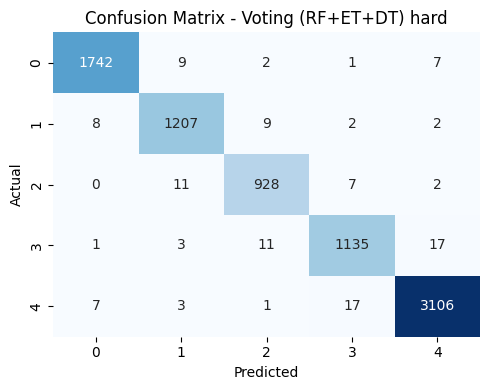


🔹 Training XGBoost...


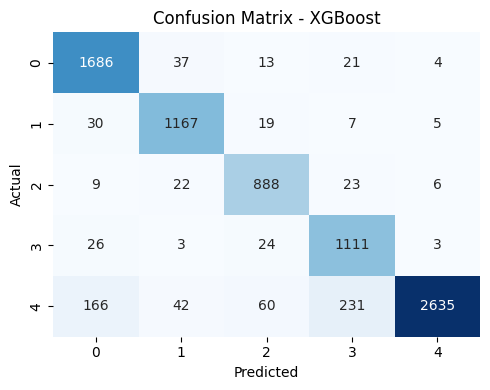


🔹 Training LightGBM...
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000477 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2805
[LightGBM] [Info] Number of data points in the train set: 62781, number of used features: 11
[LightGBM] [Info] Using GOSS
[LightGBM] [Info] Start training from score -1.595063
[LightGBM] [Info] Start training from score -1.597657
[LightGBM] [Info] Start training from score -1.627698
[Light

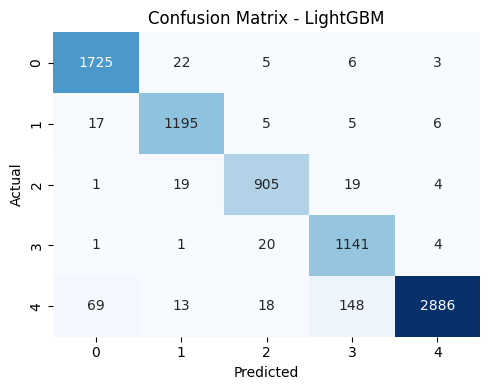


🔹 Training CatBoost...


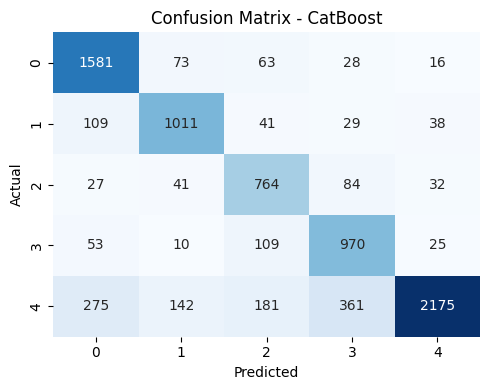


📊 Perbandingan Model Ensemble:
                                         Percobaan                   Model  \
0  Baseline Normalization Performa Ensemble adasyn                AdaBoost   
1  Baseline Normalization Performa Ensemble adasyn        GradientBoosting   
2  Baseline Normalization Performa Ensemble adasyn  Voting (RF+ET+DT) soft   
3  Baseline Normalization Performa Ensemble adasyn  Voting (RF+ET+DT) hard   
4  Baseline Normalization Performa Ensemble adasyn                 XGBoost   
5  Baseline Normalization Performa Ensemble adasyn                LightGBM   
6  Baseline Normalization Performa Ensemble adasyn                CatBoost   

   Accuracy  Precision    Recall  F1-Score  
0  0.405560   0.397466  0.413836  0.387823  
1  0.801772   0.779199  0.818170  0.792387  
2  0.984098   0.980469  0.981572  0.980999  
3  0.985433   0.982691  0.982932  0.982809  
4  0.908837   0.894582  0.927447  0.907849  
5  0.953144   0.943258  0.961183  0.951193  
6  0.789148   0.766995  0.81

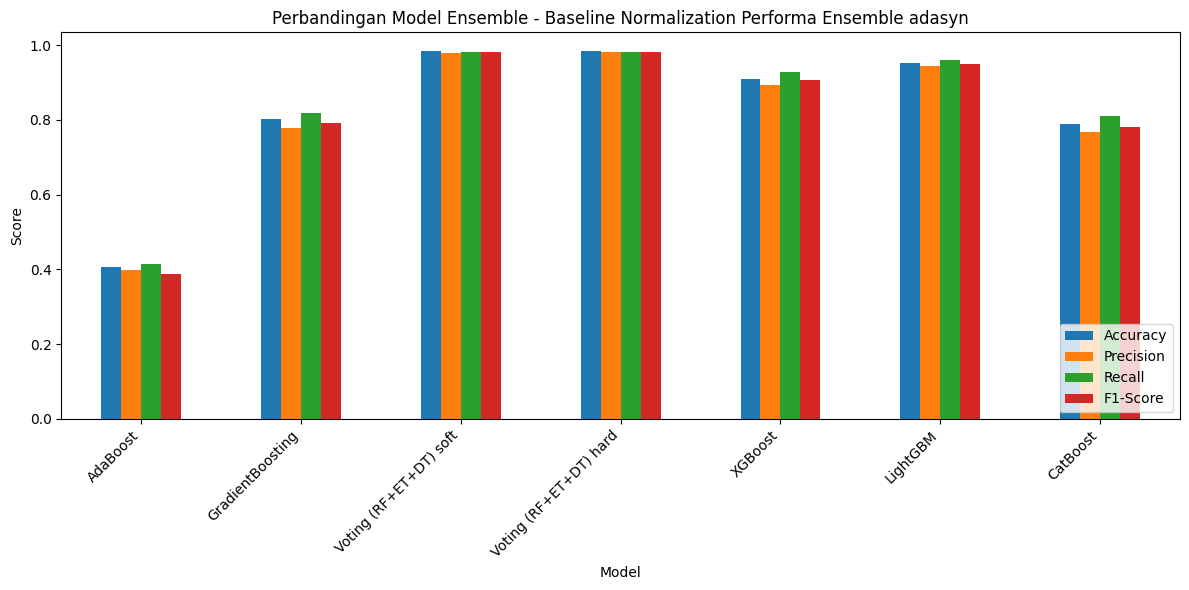

In [182]:
# === Cara pakai ===
df_results = evaluate_ensemble_models(
    X_train_scaled, X_test_scaled, y_train_ada, y_test,
    percobaan="Baseline Normalization Performa Ensemble adasyn",
    output_file="hasil_ensemble1.csv"
)

In [183]:
from sklearn.decomposition import PCA

# Inisialisasi PCA dengan 8 komponen
pca = PCA(n_components=8)

# Fit hanya di data train
X_train_pca = pca.fit_transform(X_train_scaled)

# Transform data test pakai PCA yang sudah fit dari train
X_test_pca = pca.transform(X_test_scaled)

print("Shape train PCA:", X_train_pca.shape)
print("Shape test PCA:", X_test_pca.shape)


Shape train PCA: (62781, 8)
Shape test PCA: (8238, 8)



🔹 Training AdaBoost...


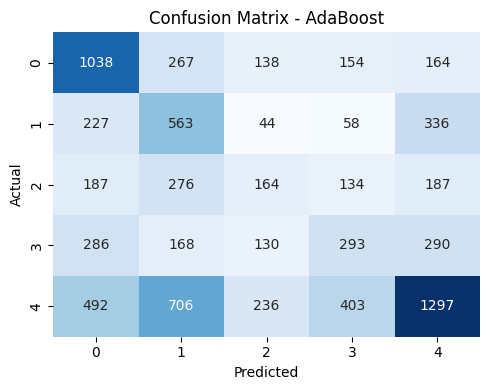


🔹 Training GradientBoosting...


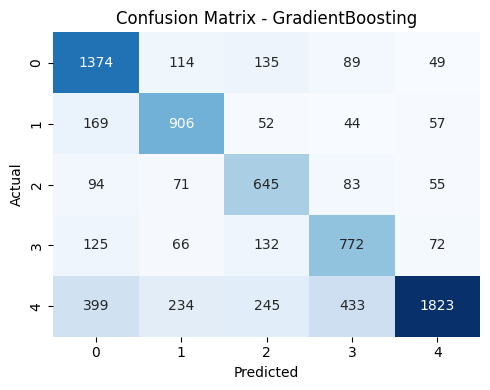


🔹 Training Voting (RF+ET+DT) soft...


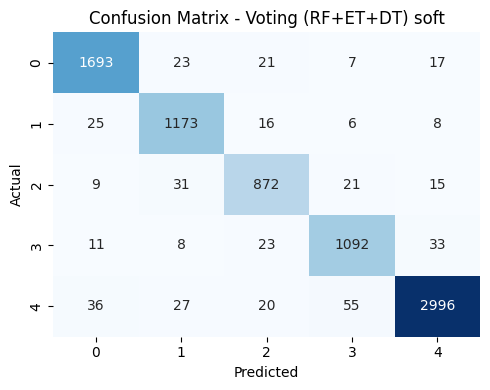


🔹 Training Voting (RF+ET+DT) hard...


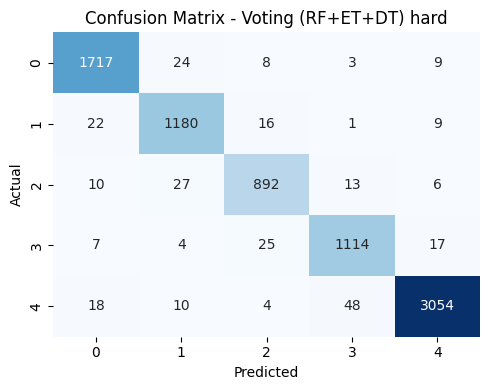


🔹 Training XGBoost...


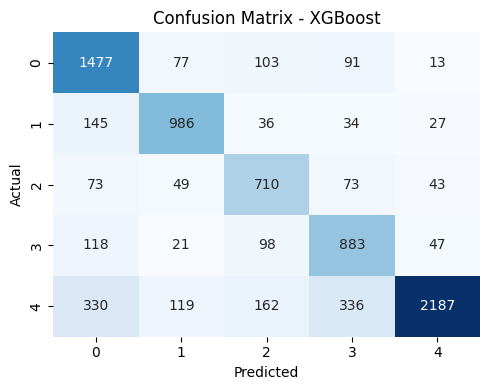


🔹 Training LightGBM...
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000961 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2040
[LightGBM] [Info] Number of data points in the train set: 62781, number of used features: 8
[LightGBM] [Info] Using GOSS
[LightGBM] [Info] Start training from score -1.595063
[LightGBM] [Info] Start training from score -1.597657
[LightGBM] [Info] Start training from score -1.627698
[LightGBM] [Info] Start training from score -1.616166
[LightGBM] [Info]

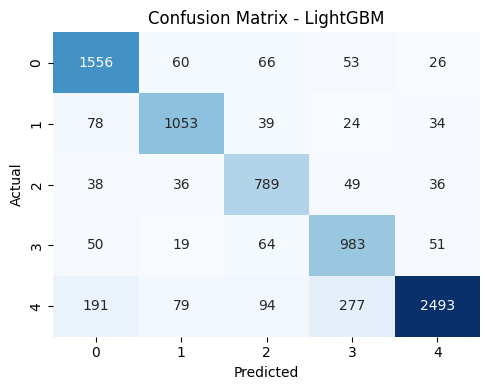


🔹 Training CatBoost...


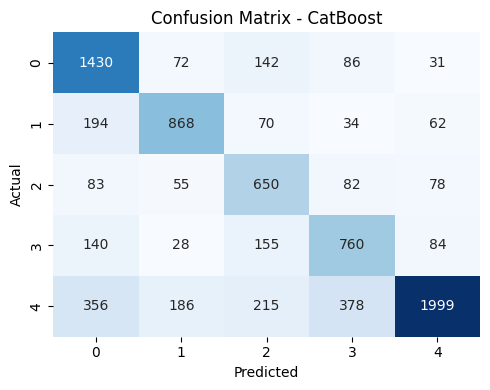


📊 Perbandingan Model Ensemble:
                        Percobaan                   Model  Accuracy  \
0  PCA 8 Performa Ensemble adasyn                AdaBoost  0.407259   
1  PCA 8 Performa Ensemble adasyn        GradientBoosting  0.670066   
2  PCA 8 Performa Ensemble adasyn  Voting (RF+ET+DT) soft  0.949988   
3  PCA 8 Performa Ensemble adasyn  Voting (RF+ET+DT) hard  0.965890   
4  PCA 8 Performa Ensemble adasyn                 XGBoost  0.757830   
5  PCA 8 Performa Ensemble adasyn                LightGBM  0.834426   
6  PCA 8 Performa Ensemble adasyn                CatBoost  0.692765   

   Precision    Recall  F1-Score  
0   0.366340  0.377164  0.362739  
1   0.650120  0.688323  0.657937  
2   0.940128  0.945626  0.942810  
3   0.958239  0.961182  0.959686  
4   0.736804  0.769015  0.745601  
5   0.812272  0.842232  0.824109  
6   0.669739  0.698724  0.675699  


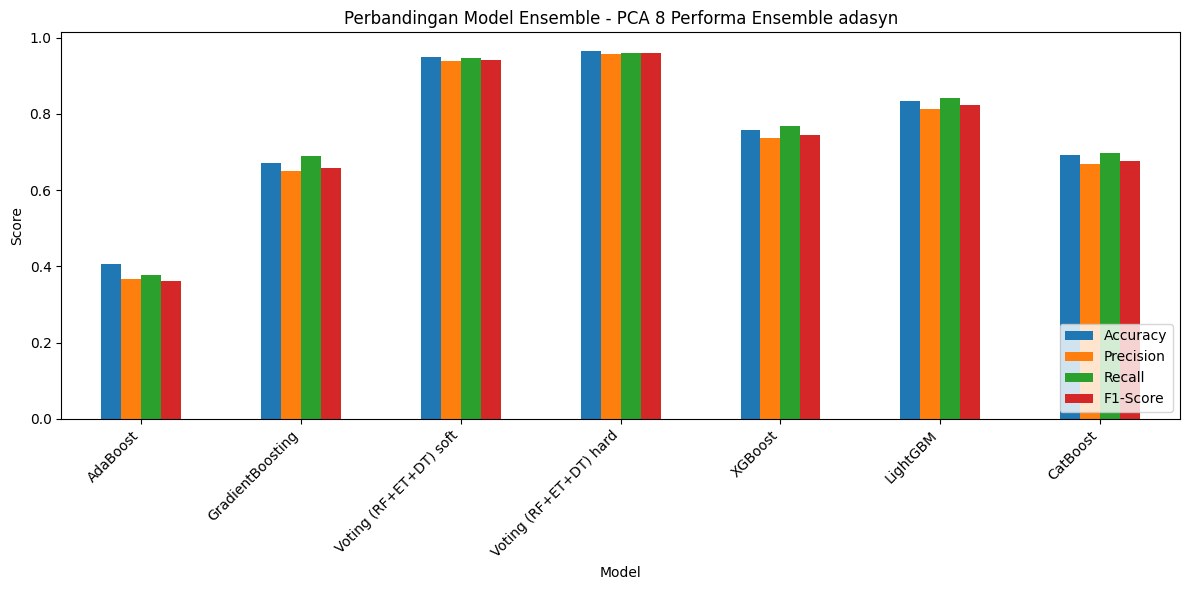

In [184]:

# === Cara pakai ===
df_results = evaluate_ensemble_models(
    X_train_pca, X_test_pca, y_train_ada, y_test,
    percobaan="PCA 8 Performa Ensemble adasyn",
    output_file="hasil_ensemble1.csv"
)


In [185]:
from sklearn.decomposition import PCA

# Inisialisasi PCA dengan 7 komponen
pca = PCA(n_components=7)

# Fit hanya di data train
X_train_pca = pca.fit_transform(X_train_scaled)

# Transform data test pakai PCA yang sudah fit dari train
X_test_pca = pca.transform(X_test_scaled)

print("Shape train PCA:", X_train_pca.shape)
print("Shape test PCA:", X_test_pca.shape)


Shape train PCA: (62781, 7)
Shape test PCA: (8238, 7)



🔹 Training AdaBoost...


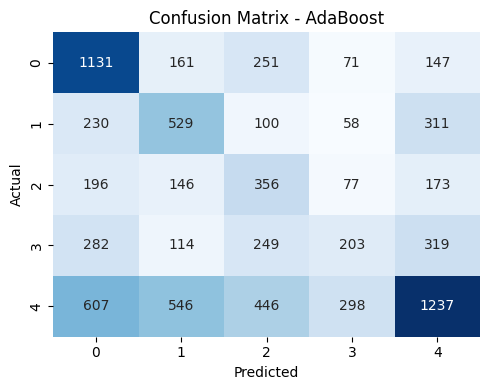


🔹 Training GradientBoosting...


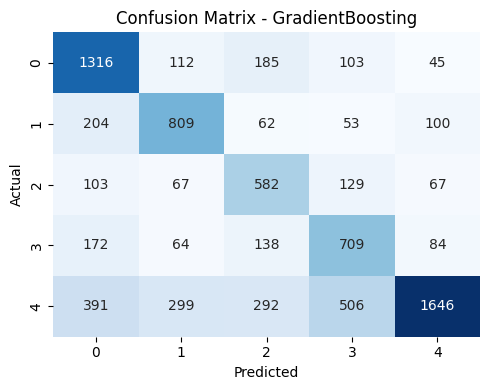


🔹 Training Voting (RF+ET+DT) soft...


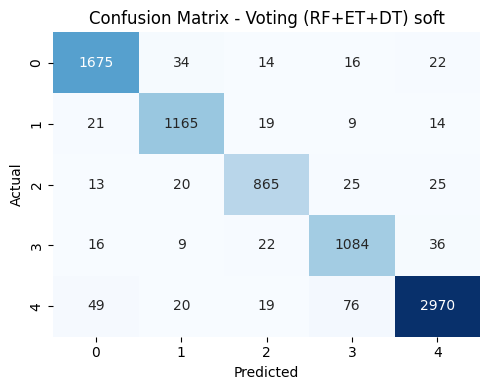


🔹 Training Voting (RF+ET+DT) hard...


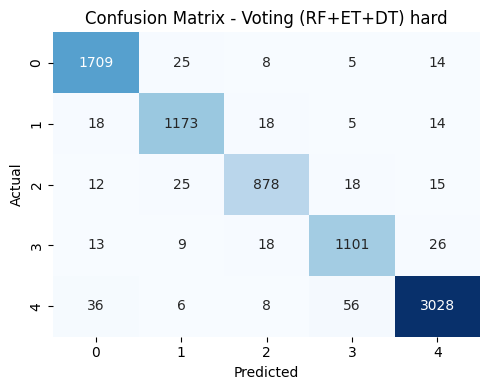


🔹 Training XGBoost...


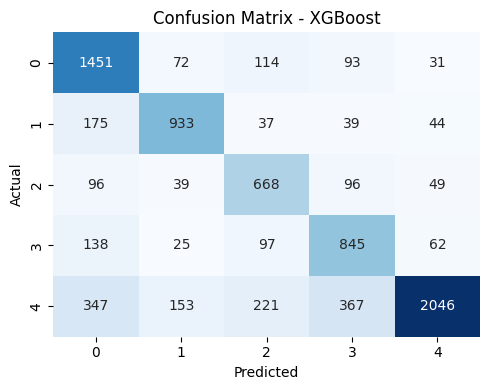


🔹 Training LightGBM...
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000256 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1785
[LightGBM] [Info] Number of data points in the train set: 62781, number of used features: 7
[LightGBM] [Info] Using GOSS
[LightGBM] [Info] Start training from score -1.595063
[LightGBM] [Info] Start training from score -1.597657
[LightGBM] [Info] Start training from score -1.627698
[LightG

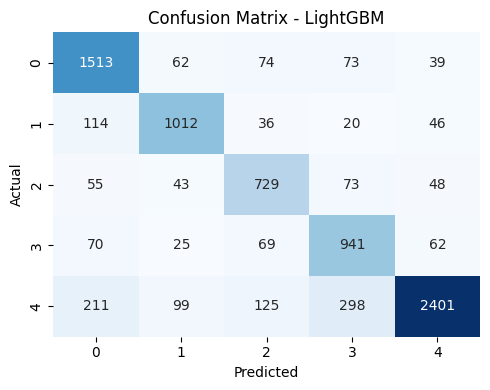


🔹 Training CatBoost...


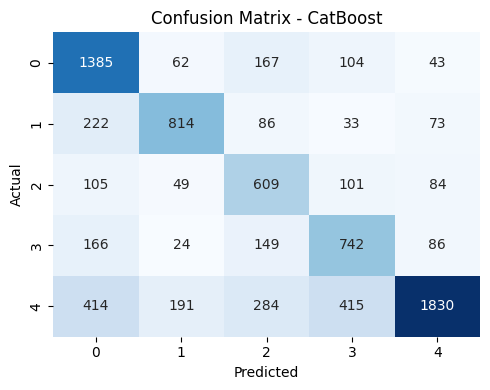


📊 Perbandingan Model Ensemble:
                        Percobaan                   Model  Accuracy  \
0  PCA 7 Performa Ensemble adasyn                AdaBoost  0.419519   
1  PCA 7 Performa Ensemble adasyn        GradientBoosting  0.614470   
2  PCA 7 Performa Ensemble adasyn  Voting (RF+ET+DT) soft  0.941855   
3  PCA 7 Performa Ensemble adasyn  Voting (RF+ET+DT) hard  0.957635   
4  PCA 7 Performa Ensemble adasyn                 XGBoost  0.721413   
5  PCA 7 Performa Ensemble adasyn                LightGBM  0.800680   
6  PCA 7 Performa Ensemble adasyn                CatBoost  0.653071   

   Precision    Recall  F1-Score  
0   0.384533  0.403442  0.382131  
1   0.596669  0.630554  0.600370  
2   0.932624  0.937771  0.935097  
3   0.950847  0.952293  0.951521  
4   0.702388  0.733059  0.708917  
5   0.777315  0.804943  0.787619  
6   0.637064  0.662299  0.638069  


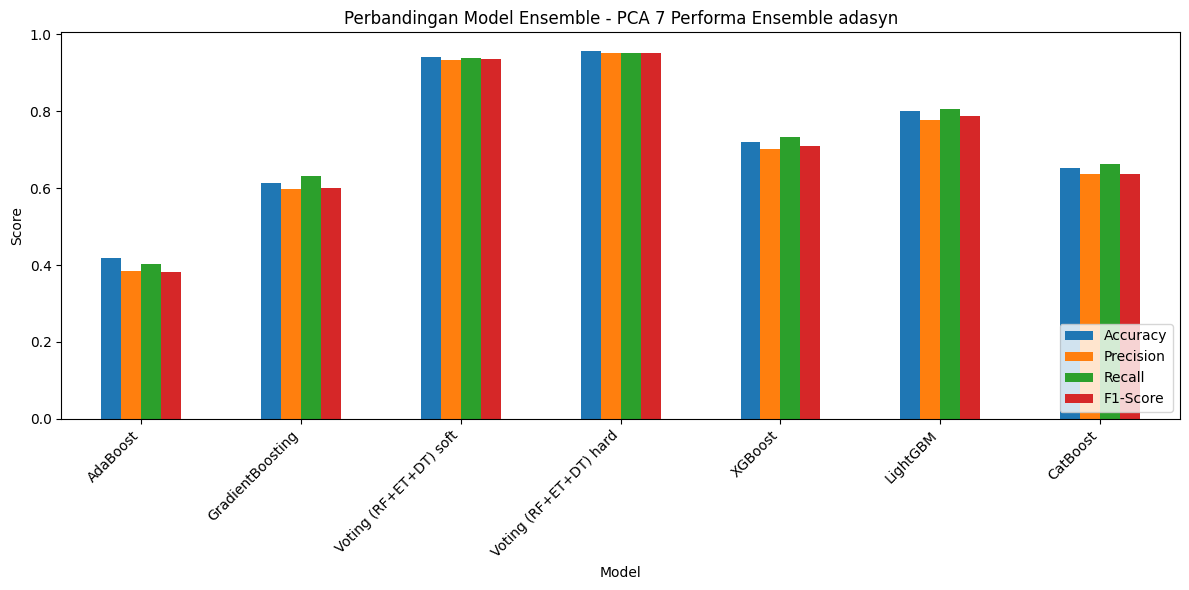

In [186]:

# === Cara pakai ===
df_results = evaluate_ensemble_models(
    X_train_pca, X_test_pca, y_train_ada, y_test,
    percobaan="PCA 7 Performa Ensemble adasyn",
    output_file="hasil_ensemble1.csv"
)


In [187]:
from sklearn.decomposition import PCA

# Inisialisasi PCA dengan 7 komponen
pca = PCA(n_components=6)

# Fit hanya di data train
X_train_pca = pca.fit_transform(X_train_scaled)

# Transform data test pakai PCA yang sudah fit dari train
X_test_pca = pca.transform(X_test_scaled)

print("Shape train PCA:", X_train_pca.shape)
print("Shape test PCA:", X_test_pca.shape)


Shape train PCA: (62781, 6)
Shape test PCA: (8238, 6)



🔹 Training AdaBoost...


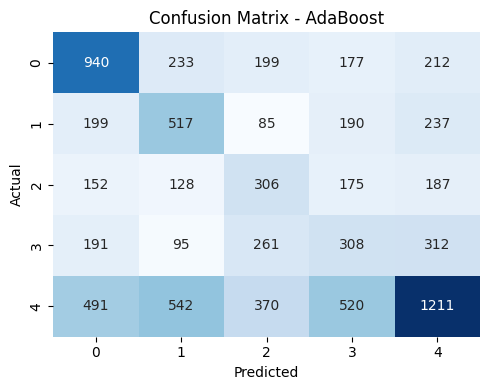


🔹 Training GradientBoosting...


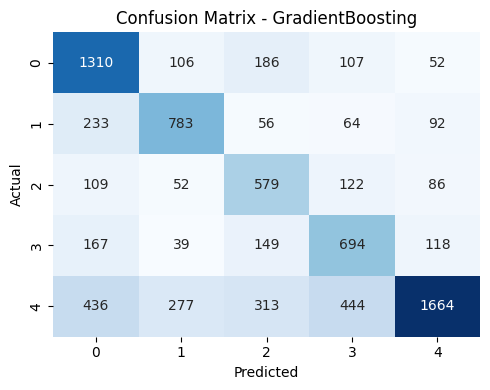


🔹 Training Voting (RF+ET+DT) soft...


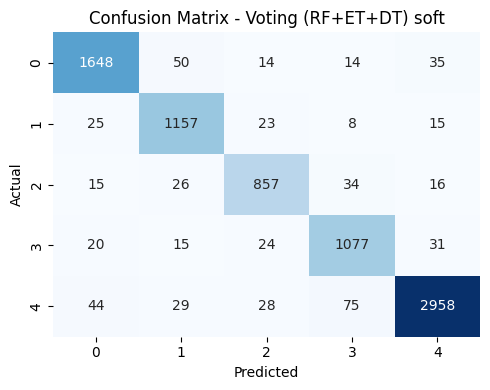


🔹 Training Voting (RF+ET+DT) hard...


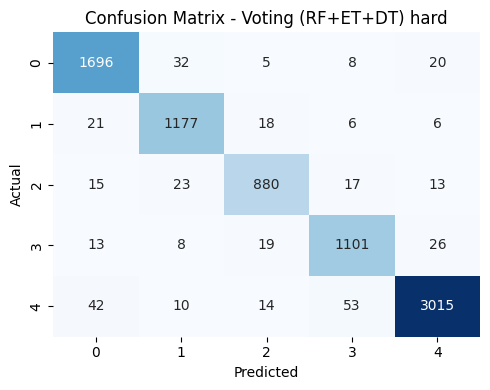


🔹 Training XGBoost...


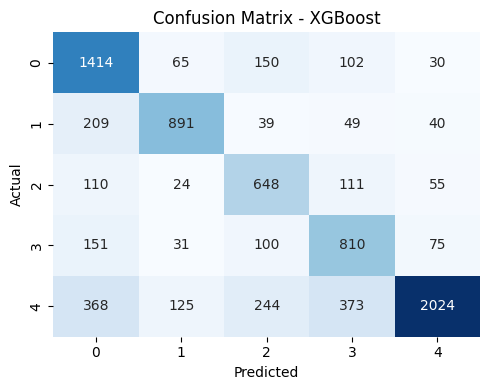


🔹 Training LightGBM...
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000696 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 62781, number of used features: 6
[LightGBM] [Info] Using GOSS
[LightGBM] [Info] Start training from score -1.595063
[LightGBM] [Info] Start training from score -1.597657
[LightGBM] [Info] Start training from score -1.627698
[LightGBM] [Info] Start training from score -1.616166
[LightGBM] [Info]

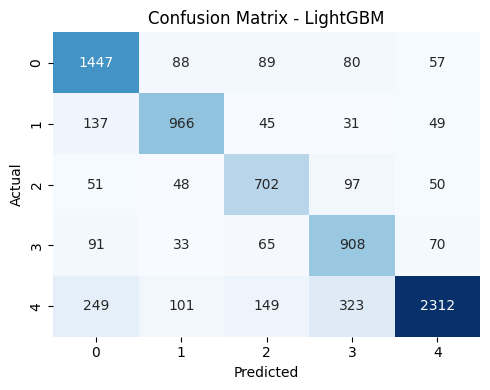


🔹 Training CatBoost...


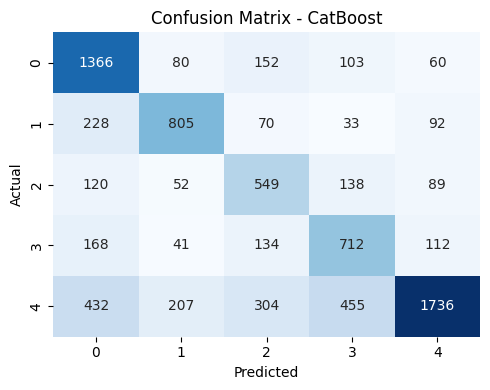


📊 Perbandingan Model Ensemble:
                        Percobaan                   Model  Accuracy  \
0  PCA 6 Performa Ensemble adasyn                AdaBoost  0.398398   
1  PCA 6 Performa Ensemble adasyn        GradientBoosting  0.610585   
2  PCA 6 Performa Ensemble adasyn  Voting (RF+ET+DT) soft  0.934329   
3  PCA 6 Performa Ensemble adasyn  Voting (RF+ET+DT) hard  0.955208   
4  PCA 6 Performa Ensemble adasyn                 XGBoost  0.702476   
5  PCA 6 Performa Ensemble adasyn                LightGBM  0.768997   
6  PCA 6 Performa Ensemble adasyn                CatBoost  0.627337   

   Precision    Recall  F1-Score  
0   0.370805  0.385583  0.372598  
1   0.593428  0.623583  0.596519  
2   0.922479  0.929749  0.925956  
3   0.947772  0.951060  0.949358  
4   0.686306  0.710395  0.688595  
5   0.744946  0.772924  0.754701  
6   0.609772  0.634877  0.611491  


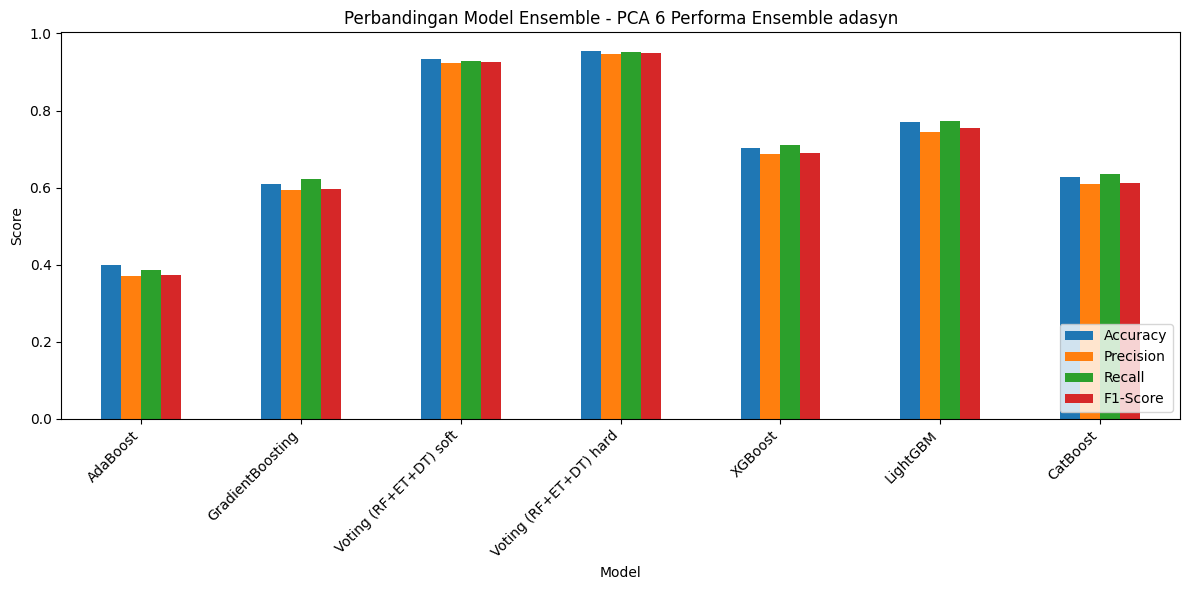

In [188]:

# === Cara pakai ===
df_results = evaluate_ensemble_models(
    X_train_pca, X_test_pca, y_train_ada, y_test,
    percobaan="PCA 6 Performa Ensemble adasyn",
    output_file="hasil_ensemble1.csv"
)


In [189]:
from sklearn.decomposition import PCA

# Inisialisasi PCA dengan 7 komponen
pca = PCA(n_components=5)

# Fit hanya di data train
X_train_pca = pca.fit_transform(X_train_scaled)

# Transform data test pakai PCA yang sudah fit dari train
X_test_pca = pca.transform(X_test_scaled)

print("Shape train PCA:", X_train_pca.shape)
print("Shape test PCA:", X_test_pca.shape)


Shape train PCA: (62781, 5)
Shape test PCA: (8238, 5)



🔹 Training AdaBoost...


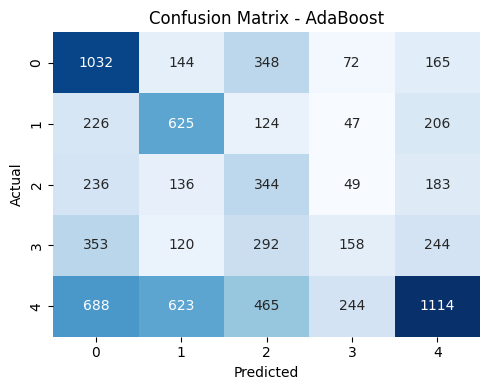


🔹 Training GradientBoosting...


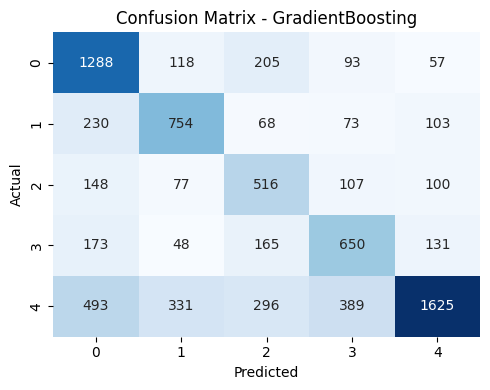


🔹 Training Voting (RF+ET+DT) soft...


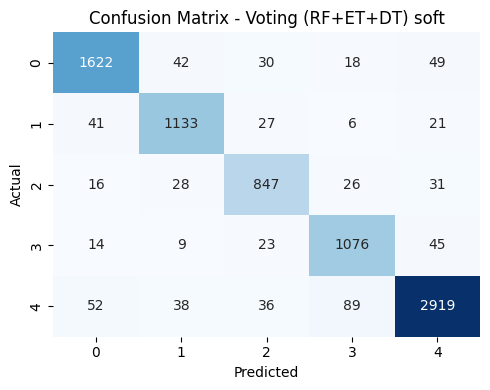


🔹 Training Voting (RF+ET+DT) hard...


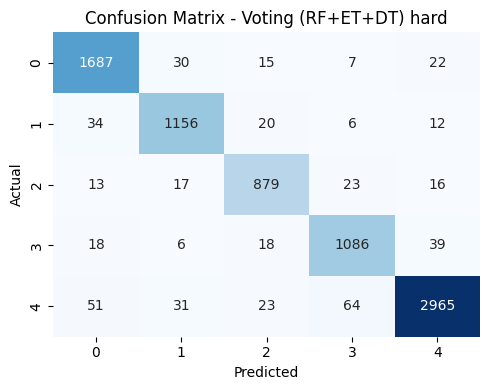


🔹 Training XGBoost...


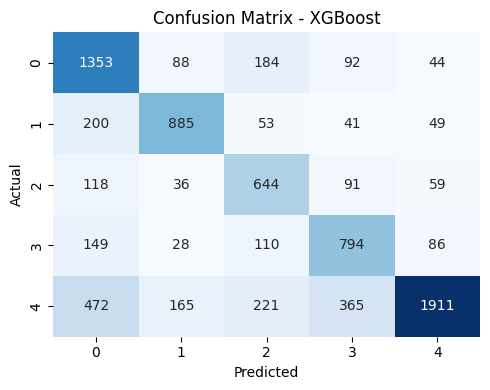


🔹 Training LightGBM...
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000803 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 62781, number of used features: 5
[LightGBM] [Info] Using GOSS
[LightGBM] [Info] Start training from score -1.595063
[LightGBM] [Info] Start training from score -1.597657
[LightGBM] [Info] Start training from score -1.627698
[LightGBM] [Info] Start training from score -1.616166
[LightGBM] [Info]

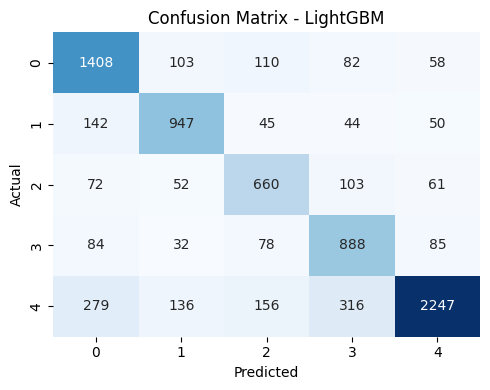


🔹 Training CatBoost...


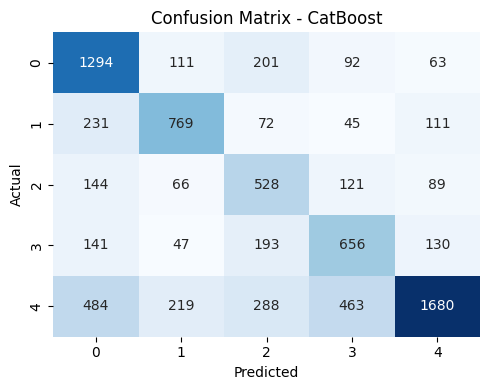


📊 Perbandingan Model Ensemble:
                        Percobaan                   Model  Accuracy  \
0  PCA 5 Performa Ensemble adasyn                AdaBoost  0.397305   
1  PCA 5 Performa Ensemble adasyn        GradientBoosting  0.586672   
2  PCA 5 Performa Ensemble adasyn  Voting (RF+ET+DT) soft  0.922190   
3  PCA 5 Performa Ensemble adasyn  Voting (RF+ET+DT) hard  0.943554   
4  PCA 5 Performa Ensemble adasyn                 XGBoost  0.678199   
5  PCA 5 Performa Ensemble adasyn                LightGBM  0.746540   
6  PCA 5 Performa Ensemble adasyn                CatBoost  0.598082   

   Precision    Recall  F1-Score  
0   0.372974  0.389741  0.362289  
1   0.566873  0.593041  0.568868  
2   0.910684  0.918117  0.914274  
3   0.934976  0.940646  0.937734  
4   0.664261  0.691693  0.667709  
5   0.720456  0.748964  0.730305  
6   0.579449  0.603235  0.580621  


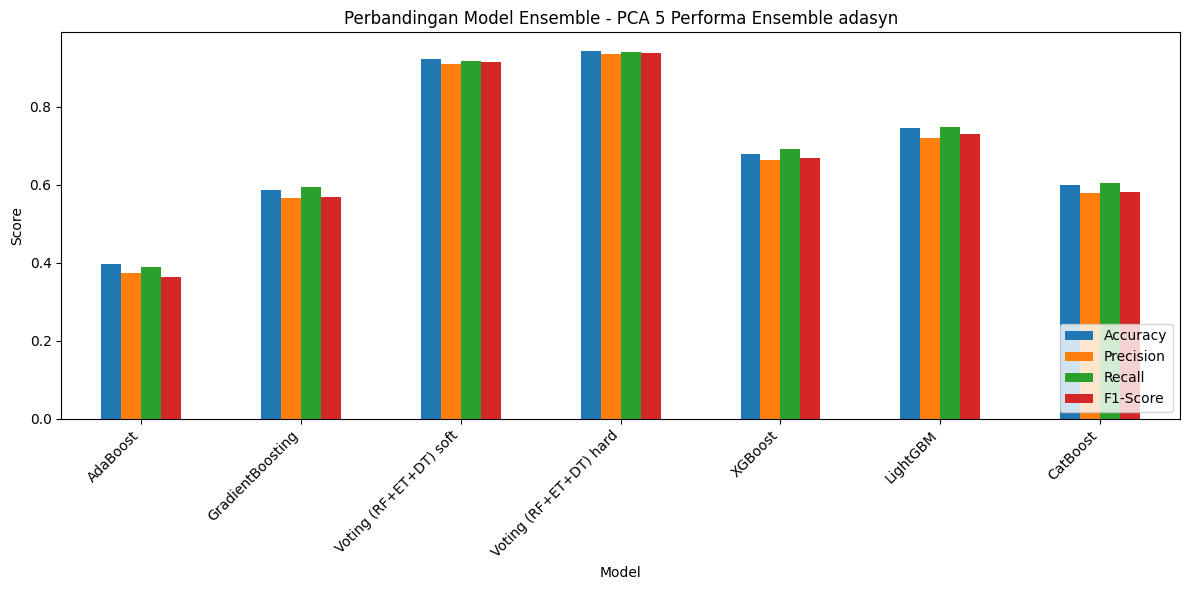

In [190]:

# === Cara pakai ===
df_results = evaluate_ensemble_models(
    X_train_pca, X_test_pca, y_train_ada, y_test,
    percobaan="PCA 5 Performa Ensemble adasyn",
    output_file="hasil_ensemble1.csv"
)
